<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# **BOW y MLP**

Importamos lo necesario

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from IPython.display import Image

Comprobamos la GPU

In [2]:
print("TensorFlow:", tf.__version__)

print("\nGPU:")
print(tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0

GPU:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Definimos el tamaño del vocabulario

In [3]:
vocab_size = 5000

Cargamos el dataset de IMDB

In [4]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size)

print("\nTrain Shape:")
print(X_train.shape)

print("\nTest Shape:")
print(X_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Train Shape:
(25000,)

Test Shape:
(25000,)


Convertimos las secuencias a Bag of Words

In [5]:
def sequences_to_bow(sequences, dimension):

    results = np.zeros(
        (len(sequences), dimension)
    )

    for i, sequence in enumerate(sequences):

        for word_idx in sequence:

            if word_idx < dimension:

                results[i, word_idx] += 1

    return results

Creamos los Bag of Words

In [6]:
X_train_bow = sequences_to_bow(
    X_train,
    vocab_size
)

X_test_bow = sequences_to_bow(
    X_test,
    vocab_size
)

print("\nBOW Train Shape:")
print(X_train_bow.shape)

print("\nBOW Test Shape:")
print(X_test_bow.shape)


BOW Train Shape:
(25000, 5000)

BOW Test Shape:
(25000, 5000)


Definimos la entrada de nuestro MLP

In [7]:
input_layer = Input(
    shape=(vocab_size,)
)

Definimos el primer bloque del MLP

In [8]:
dense1 = Dense(
    512,
    activation="relu",
    kernel_regularizer=l2(1e-4)
)(input_layer)

dense1 = BatchNormalization()(dense1)
dense1 = Dropout(0.5)(dense1)

Definimos el segundo bloque del MLP

In [9]:
dense2 = Dense(
    256,
    activation="relu",
    kernel_regularizer=l2(1e-4)
)(dense1)

dense2 = BatchNormalization()(dense2)
dense2 = Dropout(0.5)(dense2)

Definimos el tercer bloque del MLP

In [10]:
dense3 = Dense(
    128,
    activation="relu",
    kernel_regularizer=l2(1e-4)
)(dense2)

dense3 = BatchNormalization()(dense3)
dense3 = Dropout(0.5)(dense3)

Definimos la salida del MLP

In [11]:
output_layer = Dense(
    1,
    activation="sigmoid"
)(dense3)

Armamos el modelo

In [12]:
model = Model(
    inputs=input_layer,
    outputs=output_layer
)

Compilamos el modelo

In [13]:
model.compile(
    optimizer=Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Definimos el early stopping

In [14]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

Entrenamos el modelo

In [15]:
history = model.fit(
    X_train_bow,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5794 - loss: 0.9791 - val_accuracy: 0.7740 - val_loss: 0.6227
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7272 - loss: 0.7120 - val_accuracy: 0.8400 - val_loss: 0.5080
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8060 - loss: 0.5699 - val_accuracy: 0.8742 - val_loss: 0.4398
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8424 - loss: 0.5025 - val_accuracy: 0.8760 - val_loss: 0.4280
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8694 - loss: 0.4413 - val_accuracy: 0.8824 - val_loss: 0.4158
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8811 - loss: 0.4147 - val_accuracy: 0.8856 - val_loss: 0.4084
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9010 - loss: 0.3709 - val_accuracy: 0.8854 - val_loss: 0.4066
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9117 - loss: 0.3437 - val_accuracy: 0

Evaluamos el modelo

In [16]:
loss, accuracy = model.evaluate(
    X_test_bow,
    y_test
)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8813 - loss: 0.4109


Obtenemos el accuracy y su plot

FINAL TEST ACCURACY:
0.8813199996948242


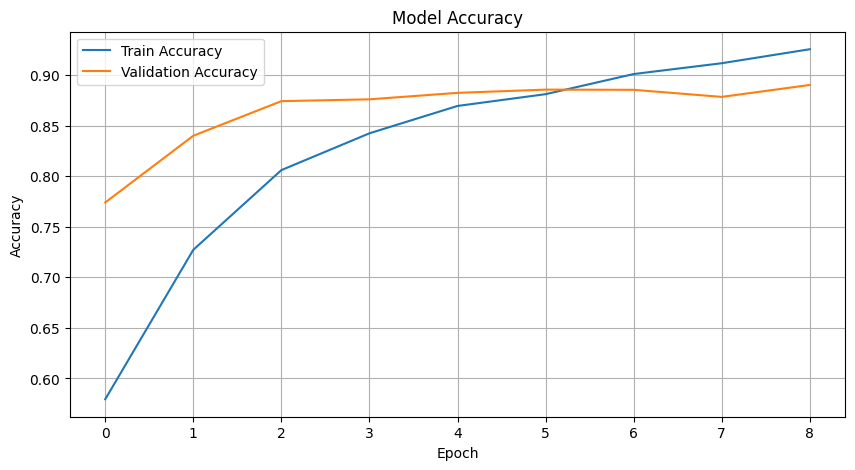

In [17]:
print("FINAL TEST ACCURACY:")
print(accuracy)



plt.figure(figsize=(10,5))
plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Obtenemos el plot de loss

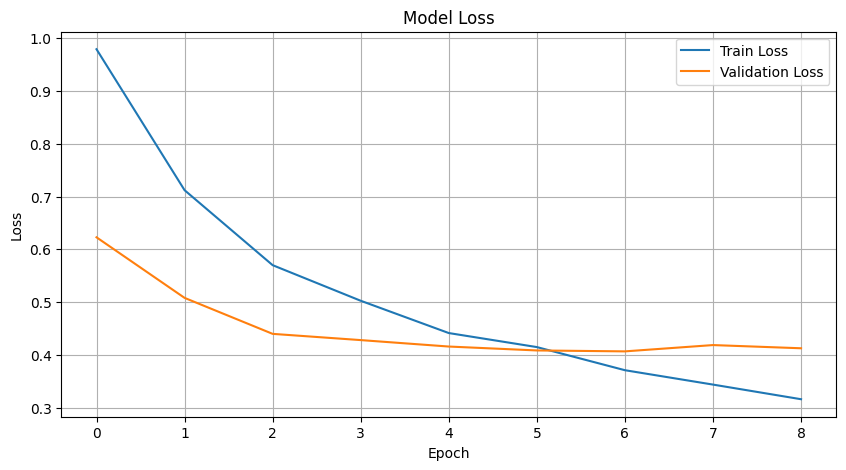

In [18]:
plt.figure(figsize=(10,5))
plt.plot(
    history.history["loss"],
    label="Train Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### **Parte C) Inferencia**

Obtenemos el word index

In [19]:
word_index = imdb.get_word_index()

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Definimos la función para convertir el texto a BoW

In [20]:
def encode_text_bow(text):

    text = text.lower()
    tokens = text.split()
    vector = np.zeros(vocab_size)

    for word in tokens:
        idx = word_index.get(word)

        if idx is not None:
            idx += 3

            if idx < vocab_size:
                vector[idx] += 1

    return np.expand_dims(vector, axis=0)

Definimos la función para realizar inferencia

In [21]:
def predict_sentiment(text):

    encoded = encode_text_bow(text)

    prediction = model.predict(
        encoded,
        verbose=0
    )[0][0]

    print("TEXT:")
    print(text)

    print("\nPREDICTION SCORE:")
    print(round(float(prediction), 4))

    if prediction >= 0.5:
        print("\nSENTIMIENTO: POSITIVO")
    else:
        print("\nSENTIMIENTO: NEGATIVO")

    print("====================================")

Realizamos inferencia en nuevas secuecias

In [22]:
predict_sentiment("this movie was amazing i loved it")

predict_sentiment("this film was terrible and boring")

predict_sentiment("the actors were fantastic and the story was beautiful")

predict_sentiment("worst movie ever")

TEXT:
this movie was amazing i loved it

PREDICTION SCORE:
0.9561

SENTIMIENTO: POSITIVO
TEXT:
this film was terrible and boring

PREDICTION SCORE:
0.0166

SENTIMIENTO: NEGATIVO
TEXT:
the actors were fantastic and the story was beautiful

PREDICTION SCORE:
0.8092

SENTIMIENTO: POSITIVO
TEXT:
worst movie ever

PREDICTION SCORE:
0.0356

SENTIMIENTO: NEGATIVO
